In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
social_media_df = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/Social Media and Mental Health.csv')


In [4]:
social_media_df.head()

,Timestamp,Gender ?,Your City,"On average, how many hours per day do you spend on social media?",What is your age?,Current Occuption,Which social media platform do you use the most?,What type of content do you consume most? (Select all that apply),How many hours of sleep do you get on average per night?,Do you use social media right before sleeping?,...,"In a few words, describe how you feel when you see your friends having fun without you on social media.",With how many specific people do you interact (DM/Tag) on a daily basis?,How would you rate your current daily stress level?,What is your current CGPA range?,Why do you usually open social media when you are supposed to be studying?,Do you use social media to escape or forget about your real-life problems?,How often do you get into arguments or heated discussions in comment sections?,How does it affect your mood if a post you made gets fewer likes than you expected?,"Have you ever experienced any negative events on social media? (cyberbullying, harassment, hate comments, etc.)",Do you have any medically approved mental disorder?
0,15/12/2025 20:18:05,Female,Peshawar,3.0,18-30,Employed,Instagram,Educational/Informative,5-7,Sometimes,...,I feel nothing,More than 10 people,1.0,3.1–3.5,U tube,Yes,1.0,It doesn't matter,No,No
1,15/12/2025 20:43:09,Male,Chitral,4.0,18-30,Student,Instagram,Friends/Family updates,5-7,Often,...,Sort of not feeling good,0 (I just scroll),2.0,3.1–3.5,To get distracted,Yes,1.0,I Feel Bad,Yes,No
2,15/12/2025 21:21:59,Male,Peshawar,4.0,18-30,Student,Whatsapp,"Educational/Informative, Lifestyle/Influencers",5-7,Rarely,...,I m very happy at that time,1-3 people,2.0,2.5–3.0,"Goggle,YouTube,chat Gpt, Canva, capcut",No,1.0,It doesn't matter,No,No
3,15/12/2025 22:16:56,Male,Islamabad,1.0,18-30,Employed,Whatsapp,"News/Politics, Educational/Informative",5-7,Always,...,Yes he has to be happy and have to fun because...,0 (I just scroll),1.0,3.1–3.5,Yes,No,1.0,It doesn't matter,No,No
4,15/12/2025 22:44:09,Male,Chitral/Isb,10.0,18-30,Student,Whatsapp,"Entertainment/Memes, News/Politics, Educationa...",5-7,Always,...,I don't think about this one....,More than 10 people,3.0,< 2.5,IDK,Yes,1.0,It doesn't matter,Yes,No


In [5]:
social_media_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 25 columns):
 #   Column                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                             --------------  -----  
 0   Timestamp                                                                                                          110 non-null    object 
 1   Gender ?                                                                                                           110 non-null    object 
 2   Your City                                                                                                          110 non-null    object 
 3   On average, how many hours per day do you spend on social media?                                                   110 non-null    float64
 4   What is your age?         

In [6]:
social_media_df.describe()

,"On average, how many hours per day do you spend on social media?",How often do you find yourself comparing your life to others?,"Do you feel ""FOMO"" (Fear of Missing Out) when you are offline?",How would you rate your current daily stress level?,How often do you get into arguments or heated discussions in comment sections?
count,110.000000,110.000000,110.000000,110.000000,110.000000
mean,5.504091,2.500000,2.400000,2.790909,1.618182
std,3.099350,1.419071,1.409014,1.249554,1.004411
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.625000,1.000000,1.000000,2.000000,1.000000
50%,5.000000,2.000000,2.000000,3.000000,1.000000
75%,7.000000,3.000000,3.000000,3.000000,2.000000
max,16.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
social_media_df.dtypes

Timestamp                                                                                                             object
Gender ?                                                                                                              object
Your City                                                                                                             object
On average, how many hours per day do you spend on social media?                                                     float64
What is your age?                                                                                                     object
Current Occuption                                                                                                     object
Which social media platform do you use the most?                                                                      object
What type of content do you consume most? (Select all that apply)                                                     object


In [8]:
social_media_df.describe()

,"On average, how many hours per day do you spend on social media?",How often do you find yourself comparing your life to others?,"Do you feel ""FOMO"" (Fear of Missing Out) when you are offline?",How would you rate your current daily stress level?,How often do you get into arguments or heated discussions in comment sections?
count,110.000000,110.000000,110.000000,110.000000,110.000000
mean,5.504091,2.500000,2.400000,2.790909,1.618182
std,3.099350,1.419071,1.409014,1.249554,1.004411
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.625000,1.000000,1.000000,2.000000,1.000000
50%,5.000000,2.000000,2.000000,3.000000,1.000000
75%,7.000000,3.000000,3.000000,3.000000,2.000000
max,16.000000,5.000000,5.000000,5.000000,5.000000


In [9]:
social_media_df.describe().T

,count,mean,std,min,25%,50%,75%,max
"On average, how many hours per day do you spend on social media?",110.0,5.504091,3.099350,1.0,3.625,5.0,7.0,16.0
How often do you find yourself comparing your life to others?,110.0,2.500000,1.419071,1.0,1.000,2.0,3.0,5.0
"Do you feel ""FOMO"" (Fear of Missing Out) when you are offline?",110.0,2.400000,1.409014,1.0,1.000,2.0,3.0,5.0
How would you rate your current daily stress level?,110.0,2.790909,1.249554,1.0,2.000,3.0,3.0,5.0
How often do you get into arguments or heated discussions in comment sections?,110.0,1.618182,1.004411,1.0,1.000,1.0,2.0,5.0


    Performing the exploratory analysis and validate the null values existing in the dataframe of social media

In [10]:
social_media_df.isnull().sum()

Timestamp                                                                                                            0
Gender ?                                                                                                             0
Your City                                                                                                            0
On average, how many hours per day do you spend on social media?                                                     0
What is your age?                                                                                                    0
Current Occuption                                                                                                    0
Which social media platform do you use the most?                                                                     0
What type of content do you consume most? (Select all that apply)                                                    0
How many hours of sleep do you get on average pe

In [11]:
social_media_df_copy = social_media_df.copy(deep=True)

In [12]:
social_media_df_copy.head()

,Timestamp,Gender ?,Your City,"On average, how many hours per day do you spend on social media?",What is your age?,Current Occuption,Which social media platform do you use the most?,What type of content do you consume most? (Select all that apply),How many hours of sleep do you get on average per night?,Do you use social media right before sleeping?,...,"In a few words, describe how you feel when you see your friends having fun without you on social media.",With how many specific people do you interact (DM/Tag) on a daily basis?,How would you rate your current daily stress level?,What is your current CGPA range?,Why do you usually open social media when you are supposed to be studying?,Do you use social media to escape or forget about your real-life problems?,How often do you get into arguments or heated discussions in comment sections?,How does it affect your mood if a post you made gets fewer likes than you expected?,"Have you ever experienced any negative events on social media? (cyberbullying, harassment, hate comments, etc.)",Do you have any medically approved mental disorder?
0,15/12/2025 20:18:05,Female,Peshawar,3.0,18-30,Employed,Instagram,Educational/Informative,5-7,Sometimes,...,I feel nothing,More than 10 people,1.0,3.1–3.5,U tube,Yes,1.0,It doesn't matter,No,No
1,15/12/2025 20:43:09,Male,Chitral,4.0,18-30,Student,Instagram,Friends/Family updates,5-7,Often,...,Sort of not feeling good,0 (I just scroll),2.0,3.1–3.5,To get distracted,Yes,1.0,I Feel Bad,Yes,No
2,15/12/2025 21:21:59,Male,Peshawar,4.0,18-30,Student,Whatsapp,"Educational/Informative, Lifestyle/Influencers",5-7,Rarely,...,I m very happy at that time,1-3 people,2.0,2.5–3.0,"Goggle,YouTube,chat Gpt, Canva, capcut",No,1.0,It doesn't matter,No,No
3,15/12/2025 22:16:56,Male,Islamabad,1.0,18-30,Employed,Whatsapp,"News/Politics, Educational/Informative",5-7,Always,...,Yes he has to be happy and have to fun because...,0 (I just scroll),1.0,3.1–3.5,Yes,No,1.0,It doesn't matter,No,No
4,15/12/2025 22:44:09,Male,Chitral/Isb,10.0,18-30,Student,Whatsapp,"Entertainment/Memes, News/Politics, Educationa...",5-7,Always,...,I don't think about this one....,More than 10 people,3.0,< 2.5,IDK,Yes,1.0,It doesn't matter,Yes,No


In [13]:
social_media_df.columns

Index(['Timestamp', 'Gender ?', 'Your City',
       'On average, how many hours per day do you spend on social media?',
       'What is your age?', 'Current Occuption',
       'Which social media platform do you use the most?',
       'What type of content do you consume most? (Select all that apply)',
       'How many hours of sleep do you get on average per night?',
       'Do you use social media right before sleeping?  ',
       'Do you check social media immediately after waking up?  ',
       'When you receive a notification while studying, what is your immediate reaction?',
       '  What is the specific thing about social media that causes you the most stress or anxiety?  ',
       'How often do you find yourself comparing your life to others?',
       'Do you feel "FOMO" (Fear of Missing Out) when you are offline?',
       'In a few words, describe how you feel when you see your friends having fun without you on social media.',
       'With how many specific people do you inte

In [18]:
print(social_media_df_copy.columns.tolist())

['Timestamp', 'Gender ?', 'Your City', 'On average, how many hours per day do you spend on social media?', 'What is your age?', 'Current Occuption', 'Which social media platform do you use the most?', 'What type of content do you consume most? (Select all that apply)', 'How many hours of sleep do you get on average per night?', 'Do you use social media right before sleeping?  ', 'Do you check social media immediately after waking up?  ', 'When you receive a notification while studying, what is your immediate reaction?', '  What is the specific thing about social media that causes you the most stress or anxiety?  ', 'How often do you find yourself comparing your life to others?', 'Do you feel "FOMO" (Fear of Missing Out) when you are offline?', 'In a few words, describe how you feel when you see your friends having fun without you on social media.', 'With how many specific people do you interact (DM/Tag) on a daily basis?', 'How would you rate your current daily stress level?', 'What is

In [20]:
cluster_cols = [ 'What is your age?', 'Gender ?', 'Your City', 'Current Occuption', 'On average, how many hours per day do you spend on social media?', 'Do you have any medically approved mental disorder?' ]

In [22]:
social_media_cluster = social_media_df_copy[cluster_cols].copy()

In [23]:
# Encode categorical columns

In [29]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans

In [30]:
label_encoder = {}

In [31]:
for col in social_media_cluster.columns:
    if social_media_cluster[col].dtype == 'object':
        le = LabelEncoder()
        social_media_cluster[col] = le.fit_transform(social_media_cluster[col].astype(str))
        label_encoder[col] = le

In [32]:
### Scale the data : 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(social_media_cluster)

In [33]:
### Run K means clustering :
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

KMeans(n_clusters=3, random_state=42)

In [34]:
social_media_cluster['cluster'] = kmeans.fit_predict(scaled_data)

In [38]:
cluster_data = social_media_df_copy[cluster_cols]
cluster_data['cluster'] = social_media_cluster['cluster']

/var/folders/bt/k7t4mr2j6kq79jv3vbj756z80000gn/T/ipykernel_9839/1436373808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['cluster'] = social_media_cluster['cluster']


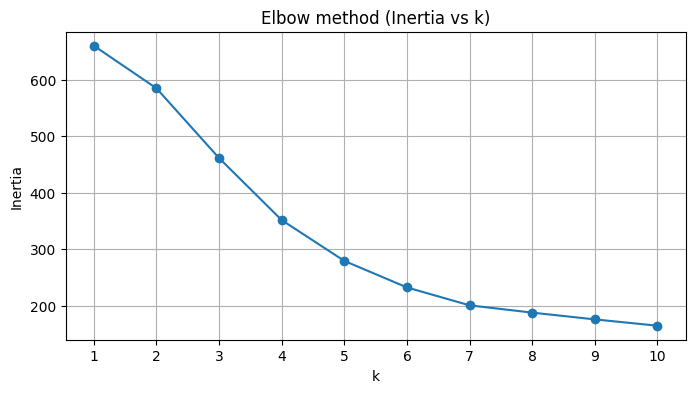

Detected elbow (k) = 5

Cluster counts:
cluster
0    10
1    40
2    21
3     4
4    35
Name: count, dtype: int64

Cluster-wise mean hours on social media:
cluster
0    12.500000
1     4.723750
2     4.285714
3     4.000000
4     5.300000
Name: On average, how many hours per day do you spend on social media?, dtype: float64

Decoded cluster centers (approximate):
        What is your age? Gender ? Your City Current Occuption  \
cluster                                                          
0                   18-30     Male   Quetta            Student   
1                   18-30     Male     Karak           Student   
2                   18-30     Male  Nowshera          Employed   
3                   12-18   Female  Peshawar           Student   
4                   18-30   Female    Lahore           Student   

         On average, how many hours per day do you spend on social media?  \
cluster                                                                     
0                

/var/folders/bt/k7t4mr2j6kq79jv3vbj756z80000gn/T/ipykernel_9839/4201005545.py:36: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(v, pts - p1)) / norm_v


In [39]:
# Elbow (k-bend) method, automatic elbow detection, and final clustering summary

# Use existing variables: scaled_data, scaler, social_media_df_copy, cluster_cols, label_encoder, KMeans, plt, np, pd

# 1. Compute inertia for k range
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

# 2. Plot inertia vs k (elbow plot)
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method (Inertia vs k)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# 3. Automatic elbow detection using max distance to line method
# convert to 2D points (k, inertia)
pts = np.column_stack((np.array(list(k_range)), np.array(inertias)))
p1 = pts[0]
p2 = pts[-1]
# vector from p1 to p2
v = p2 - p1
# compute distances from each point to the line through p1-p2
# distance = norm(cross(v, p_i - p1)) / norm(v) in 2D reduces to area formula
norm_v = np.linalg.norm(v)
if norm_v == 0:
    elbow_k = 1
else:
    distances = np.abs(np.cross(v, pts - p1)) / norm_v
    elbow_idx = np.argmax(distances)
    elbow_k = int(k_range[elbow_idx])

print(f"Detected elbow (k) = {elbow_k}")

# 4. Fit final KMeans with detected k and attach labels to original data
kmeans_opt = KMeans(n_clusters=elbow_k, random_state=42)
labels_opt = kmeans_opt.fit_predict(scaled_data)

final_cluster_data = social_media_df_copy[cluster_cols].copy()
final_cluster_data['cluster'] = labels_opt

# 5. Basic cluster counts and numeric summary
print("\nCluster counts:")
print(final_cluster_data['cluster'].value_counts().sort_index())

print("\nCluster-wise mean hours on social media:")
print(final_cluster_data.groupby('cluster')['On average, how many hours per day do you spend on social media?'].mean())

# 6. Decode cluster centers to human-readable (inverse transform for encoded categorical features)
centers_scaled = kmeans_opt.cluster_centers_
centers_unscaled = scaler.inverse_transform(centers_scaled)  # back to encoded/original space

centers_df = pd.DataFrame(centers_unscaled, columns=cluster_cols)

def decode_center_row(row):
    decoded = {}
    for col in centers_df.columns:
        val = row[col]
        # if this column was label-encoded, inverse transform the nearest integer label
        if col in label_encoder and hasattr(label_encoder[col], 'inverse_transform'):
            # round to nearest integer and clip
            label_vals = np.arange(len(label_encoder[col].classes_))
            int_val = int(np.clip(np.round(val), label_vals.min(), label_vals.max()))
            decoded[col] = label_encoder[col].inverse_transform([int_val])[0]
        else:
            # numeric column (hours)
            decoded[col] = float(round(val, 2))
    return decoded

decoded_centers = pd.DataFrame([decode_center_row(centers_df.iloc[i]) for i in range(centers_df.shape[0])])
decoded_centers.index.name = 'cluster'
print("\nDecoded cluster centers (approximate):")
print(decoded_centers)

# 7. Cluster-wise mode for categorical columns and numeric summary
cat_cols = [c for c in cluster_cols if final_cluster_data[c].dtype == 'object']
num_cols = [c for c in cluster_cols if c not in cat_cols]

mode_summary = final_cluster_data.groupby('cluster')[cat_cols].agg(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)
num_summary = final_cluster_data.groupby('cluster')[num_cols].agg(['mean', 'count'])

print("\nCluster categorical modes:")
print(mode_summary)

print("\nCluster numeric summary:")
print(num_summary)

# 8. (Optional) Save final clustering result into a dataframe for downstream analysis
final_cluster_data.reset_index(drop=True, inplace=True)
final_cluster_data.to_csv('social_media_final_clusters.csv', index=False)
print("\nFinal clustered data saved to 'social_media_final_clusters.csv'")

In [1]:
# Conclusion based on the elbow method plot
print(
    f"Elbow method detected k = {elbow_k}. "
    "This suggests using 3 clusters (k = {0}) as increasing k beyond this point yields diminishing reductions in inertia, "
    "so additional clusters likely add little explanatory value. "
    "Proceed with k = {0} and validate clusters by examining cluster sizes, decoded centers, and domain relevance."
    .format(elbow_k)
)

NameError: name 'elbow_k' is not defined